# Busqueda de configuracion optima para la LSTM

Este notebook explora el espacio de hiperparametros de la LSTM
aplicada al retorno logaritmico de AAPL en horizontes de 1 y 5 dias.
El objetivo es comprobar si alguna configuracion mejora al Naive y al
modelo del TFG (LSTM de 16 unidades, dropout 0,3, secuencia 10).

**Activo:** AAPL (acciones del S&P 500).
**Horizontes:** 1 dia y 5 dias.
**Estrategia:** rejilla estructurada de 54 configuraciones que
combinan cuatro ejes: arquitectura, regularizacion, secuencia/batch y
optimizacion (lr, optimizer, loss).
**Protocolo:** entrenamiento sobre train (<=2022), early stopping en
val (2023) y evaluacion en test (>=2024). El scaler se ajusta solo
sobre train para evitar fuga de informacion. No se aplica walk-forward
durante la busqueda: el coste seria prohibitivo y la ordenacion
relativa entre configuraciones se conserva.

## 1. Imports y configuracion global

Se reutilizan las dependencias del pipeline principal del TFG.
Se fijan semillas para garantizar reproducibilidad entre
ejecuciones.

In [1]:
import os
import sys
import time
import warnings
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_squared_error,
                             mean_absolute_error, r2_score)

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import (EarlyStopping,
                                        ReduceLROnPlateau)
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.regularizers import l2 as keras_l2
from tensorflow.keras.losses import Huber

try:
    from tensorflow.keras.optimizers import AdamW
    HAS_ADAMW = True
except ImportError:
    HAS_ADAMW = False

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.grid': True, 'grid.alpha': 0.3})
sns.set_palette('tab10')
pd.set_option('display.float_format', '{:.6f}'.format)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow: {tf.__version__}')
print(f'AdamW disponible: {HAS_ADAMW}')

TensorFlow: 2.21.0
AdamW disponible: True


## 2. Carga de datos y construccion de features

Se reutilizan las funciones de los notebooks anteriores: carga del
CSV de AAPL, descarga del VIX e ingenieria de variables del bloque
base mas regimen de volatilidad y bloque VIX. El particionado
temporal sigue el esquema fijo del TFG: train hasta 2022-12-31,
val durante 2023, test desde 2024-01-01.

In [2]:
BASE_DIR = Path(r'C:\Users\enris\Desktop\UNIVERSIDAD\Cuarto\TFG')

DIR_DATOS   = BASE_DIR / 'Datos'
DIR_STOCKS  = DIR_DATOS / 'Stocks'
RESULTS_DIR = BASE_DIR / 'Resultados'
FIGURES_DIR = BASE_DIR / 'Figuras'

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TICKER = 'AAPL'
TRAIN_END = '2022-12-31'
VAL_END   = '2023-12-31'

print(f'Activo: {TICKER}')
print(f'Particion: train <= {TRAIN_END}, '
      f'val 2023, test >= {VAL_END}')

Activo: AAPL
Particion: train <= 2022-12-31, val 2023, test >= 2023-12-31


In [3]:
def load_stock(ticker):
    path = DIR_STOCKS / f'{ticker}_2015_2026.csv'
    df = pd.read_csv(path, parse_dates=['Date'], index_col='Date')
    df.columns = [c.lower() for c in df.columns]
    df = df.rename(columns={'close':'Close','open':'Open',
                            'high':'High','low':'Low',
                            'volume':'Volume'})
    return df[['Open','High','Low','Close','Volume']].sort_index()


df_raw = load_stock(TICKER)
print(f'Sesiones cargadas: {len(df_raw):,}')
print(f'Rango: {df_raw.index[0].date()} a '
      f'{df_raw.index[-1].date()}')
df_raw.head()

Sesiones cargadas: 2,815
Rango: 2015-01-02 a 2026-03-13


,Open,High,Low,Close,Volume
Date,,,,,
2015-01-02,24.671141,24.682216,23.776344,24.214884,212818400
2015-01-05,23.984553,24.064287,23.346678,23.532724,257142000
2015-01-06,23.596948,23.794069,23.173912,23.534933,263188400
2015-01-07,23.743125,23.964610,23.632383,23.864943,160423600
2015-01-08,24.192743,24.839477,24.075355,24.781891,237458000


In [4]:
print('Descargando VIX desde Yahoo Finance...')
vix_raw = yf.download('^VIX', start='2014-01-01',
                      end='2026-06-01', progress=False)
if isinstance(vix_raw.columns, pd.MultiIndex):
    vix_raw.columns = vix_raw.columns.get_level_values(0)
vix_raw = vix_raw[['Close']].rename(
    columns={'Close': 'VIX_Close'})
vix_raw['VIX_Return_1d'] = vix_raw['VIX_Close'].pct_change()
vix_raw['VIX_SMA_20']    = vix_raw['VIX_Close'].rolling(20).mean()
vix_raw['VIX_vs_SMA20']  = (vix_raw['VIX_Close']
                            / vix_raw['VIX_SMA_20'] - 1)

VIX_FEATURES = ['VIX_Close', 'VIX_Return_1d',
                'VIX_SMA_20', 'VIX_vs_SMA20']
print(f'VIX: {len(vix_raw):,} sesiones')

Descargando VIX desde Yahoo Finance...
VIX: 3,099 sesiones


In [5]:
def add_features(df, vix_df=None):
    """Bloque base + regimen de volatilidad + VIX (opcional)."""
    d = df.copy()
    d['Return_1d']  = d['Close'].pct_change(1)
    d['Return_5d']  = d['Close'].pct_change(5)
    d['Return_10d'] = d['Close'].pct_change(10)
    d['Return_20d'] = d['Close'].pct_change(20)

    for w in [20, 50, 200]:
        d[f'SMA_{w}'] = d['Close'].rolling(w).mean()
    ema12 = d['Close'].ewm(span=12, adjust=False).mean()
    ema26 = d['Close'].ewm(span=26, adjust=False).mean()

    d['Price_vs_SMA20']  = d['Close'] / d['SMA_20']  - 1
    d['Price_vs_SMA50']  = d['Close'] / d['SMA_50']  - 1
    d['Price_vs_SMA200'] = d['Close'] / d['SMA_200'] - 1
    d['MACD']        = ema12 - ema26
    d['MACD_Signal'] = d['MACD'].ewm(span=9, adjust=False).mean()
    d['MACD_Hist']   = d['MACD'] - d['MACD_Signal']

    delta = d['Close'].diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    d['RSI_14'] = 100 - (100 / (1 + gain / loss.replace(0, np.nan)))

    bb_mid = d['Close'].rolling(20).mean()
    bb_std = d['Close'].rolling(20).std()
    bb_up  = bb_mid + 2 * bb_std
    bb_lo  = bb_mid - 2 * bb_std
    d['BB_Width']    = (bb_up - bb_lo) / bb_mid
    d['BB_Position'] = (d['Close'] - bb_lo) / (bb_up - bb_lo + 1e-8)

    tr = pd.concat([
        d['High'] - d['Low'],
        (d['High'] - d['Close'].shift(1)).abs(),
        (d['Low']  - d['Close'].shift(1)).abs()
    ], axis=1).max(axis=1)
    d['ATR_rel'] = tr.ewm(com=13, adjust=False).mean() / d['Close']

    d['Momentum_5']  = d['Close'] - d['Close'].shift(5)
    d['Momentum_10'] = d['Close'] - d['Close'].shift(10)
    d['Vol_20d']   = d['Return_1d'].rolling(20).std()
    d['Vol_rel']   = (d['Volume']
                     / (d['Volume'].rolling(20).mean() + 1e-8))
    d['Day_Range'] = (d['High'] - d['Low']) / d['Close']

    vol5  = d['Return_1d'].rolling(5).std()
    vol10 = d['Return_1d'].rolling(10).std()
    vol60 = d['Return_1d'].rolling(60).std()
    d['Vol_ratio_5_20']  = vol5  / (d['Vol_20d'] + 1e-8)
    d['Vol_ratio_10_60'] = vol10 / (vol60 + 1e-8)
    d['Vol_percentile_60'] = d['Vol_20d'].rolling(60).apply(
        lambda x: pd.Series(x).rank(pct=True).iloc[-1], raw=False)
    vol20_m = d['Vol_20d'].rolling(60).mean()
    vol20_s = d['Vol_20d'].rolling(60).std()
    d['Vol_zscore_60'] = (d['Vol_20d'] - vol20_m) / (vol20_s + 1e-8)

    log_hl = np.log(d['High'] / d['Low'])
    log_co = np.log(d['Close'] / d['Open'])
    gk = 0.5 * log_hl**2 - (2*np.log(2) - 1) * log_co**2
    d['Garman_Klass_vol'] = np.sqrt(gk.rolling(20).mean() * 252)
    d['Parkinson_vol'] = np.sqrt(
        (1 / (4*np.log(2)))
        * (np.log(d['High']/d['Low'])**2).rolling(20).mean() * 252)
    d['Vol_of_vol'] = d['Vol_20d'].rolling(20).std()
    vol_rel_60 = (d['Vol_20d']
                  / (d['Vol_20d'].rolling(60).mean() + 1e-8))
    d['Volume_vol_ratio'] = d['Vol_rel'] / (vol_rel_60 + 1e-8)

    if vix_df is not None:
        d = d.join(vix_df[VIX_FEATURES], how='left')
        for col in VIX_FEATURES:
            d[col] = d[col].ffill()

    for c in ['SMA_20', 'SMA_50', 'SMA_200']:
        d.drop(columns=[c], errors='ignore', inplace=True)
    return d


FEATURE_COLS = [
    'Return_1d','Return_5d','Return_10d','Return_20d',
    'Price_vs_SMA20','Price_vs_SMA50','Price_vs_SMA200',
    'MACD','MACD_Signal','MACD_Hist','RSI_14',
    'BB_Width','BB_Position','ATR_rel',
    'Momentum_5','Momentum_10','Vol_20d','Vol_rel','Day_Range',
    'Vol_ratio_5_20','Vol_ratio_10_60','Vol_percentile_60',
    'Vol_zscore_60','Garman_Klass_vol','Parkinson_vol',
    'Vol_of_vol','Volume_vol_ratio',
] + VIX_FEATURES

WEEKLY_FEATURES = ['Return_5d_lag1', 'Vol_5d', 'Momentum_5d',
                   'RSI_5d', 'Vol_mean_5d']


def add_weekly(df):
    d = df.copy()
    logret = np.log(d['Close'] / d['Close'].shift(1))
    d['Return_5d_lag1'] = logret.rolling(5).sum().shift(1)
    d['Vol_5d']         = logret.rolling(5).std()
    d['Momentum_5d']    = d['Close'].pct_change(5)
    delta = d['Close'].diff()
    gain  = delta.clip(lower=0).rolling(5).mean()
    loss  = (-delta.clip(upper=0)).rolling(5).mean()
    d['RSI_5d'] = 100 - (100 / (1 + gain / loss.replace(0, np.nan)))
    d['Vol_mean_5d'] = (d['Volume'].rolling(5).mean()
                       / (d['Volume'].rolling(20).mean() + 1e-8))
    return d


df_feat = add_features(df_raw, vix_df=vix_raw)
print(f'Features (1d): {len(FEATURE_COLS)}  '
      f'| (5d): {len(FEATURE_COLS) + len(WEEKLY_FEATURES)}')

Features (1d): 31  | (5d): 36


In [6]:
def prepare_dataset(df, feature_cols):
    d = df.copy()
    d['logret']    = np.log(d['Close'] / d['Close'].shift(1))
    d['target_1d'] = d['logret'].shift(-1)
    d['target_5d'] = np.log(d['Close'].shift(-5) / d['Close'])
    d = add_weekly(d)

    feats_1d = [c for c in feature_cols if c in d.columns]
    feats_5d = feats_1d + [c for c in WEEKLY_FEATURES
                           if c in d.columns]
    cols = list(set(feats_5d + ['target_1d', 'target_5d']))
    d = d.dropna(subset=cols)

    train = d.loc[:TRAIN_END]
    val   = d.loc[TRAIN_END:VAL_END].iloc[1:]
    test  = d.loc[VAL_END:].iloc[1:]
    return {
        'X_train_1d': train[feats_1d],
        'X_val_1d'  : val[feats_1d],
        'X_test_1d' : test[feats_1d],
        'X_train_5d': train[feats_5d],
        'X_val_5d'  : val[feats_5d],
        'X_test_5d' : test[feats_5d],
        'y_train_1d': train['target_1d'],
        'y_val_1d'  : val['target_1d'],
        'y_test_1d' : test['target_1d'],
        'y_train_5d': train['target_5d'],
        'y_val_5d'  : val['target_5d'],
        'y_test_5d' : test['target_5d'],
        'feats_1d': feats_1d,
        'feats_5d': feats_5d,
    }


ds = prepare_dataset(df_feat, FEATURE_COLS)
print(f"{'Split':<6} {'1d':>8} {'5d':>8}")
print('-' * 26)
print(f"Train  {len(ds['X_train_1d']):>8,} "
      f"{len(ds['X_train_5d']):>8,}")
print(f"Val    {len(ds['X_val_1d']):>8,} "
      f"{len(ds['X_val_5d']):>8,}")
print(f"Test   {len(ds['X_test_1d']):>8,} "
      f"{len(ds['X_test_5d']):>8,}")

Split        1d       5d
--------------------------
Train     1,732    1,732
Val         245      245
Test        517      517


## 3. Pipeline de evaluacion de una configuracion

La funcion `run_config` recibe una configuracion (`dict`) y devuelve
las metricas en test. Diferencias respecto al pipeline del TFG:

1. **Scaler ajustado solo sobre train.** Tanto el `StandardScaler` de
   X como el de y se ajustan unicamente con el bloque de
   entrenamiento, lo que evita la fuga residual del escalador.
2. **Sin reentrenamiento walk-forward.** El modelo se entrena una
   sola vez con early stopping sobre val y se evalua de forma
   estatica en test. Es habitual en busquedas masivas: la ordenacion
   relativa entre configuraciones se preserva aunque las metricas
   absolutas no sean comparables a las del pipeline walk-forward.
3. **Constructor flexible.** `build_model` acepta una o dos capas
   LSTM, dropout estandar y recurrente, regularizacion L2 y
   diferentes optimizadores y funciones de perdida.

In [7]:
def directional_accuracy(y_true, y_pred):
    """% de aciertos en la direccion del retorno."""
    return float(np.mean(np.sign(y_true) == np.sign(y_pred)))


def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(len(X) - seq_len + 1):
        Xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len-1])
    return np.array(Xs), np.array(ys)


def get_optimizer(name, lr):
    if name == 'adam':
        return Adam(learning_rate=lr)
    if name == 'rmsprop':
        return RMSprop(learning_rate=lr)
    if name == 'sgd_momentum':
        return SGD(learning_rate=lr, momentum=0.9)
    if name == 'adamw' and HAS_ADAMW:
        return AdamW(learning_rate=lr, weight_decay=1e-4)
    return Adam(learning_rate=lr)


def get_loss(name):
    if name == 'mse':
        return 'mse'
    if name == 'mae':
        return 'mae'
    if name == 'huber':
        return Huber(delta=1.0)
    return 'mse'


def build_model(seq_len, n_feat, cfg):
    """Construye una LSTM segun la configuracion."""
    units1 = cfg['units1']
    units2 = cfg.get('units2', 0)
    dropout = cfg.get('dropout', 0.0)
    rec_dropout = cfg.get('rec_dropout', 0.0)
    l2_reg = cfg.get('l2', 0.0)
    reg = keras_l2(l2_reg) if l2_reg > 0 else None

    layers = [Input(shape=(seq_len, n_feat))]
    if units2 > 0:
        layers.append(LSTM(
            units1, return_sequences=True,
            recurrent_dropout=rec_dropout,
            kernel_regularizer=reg))
        if dropout > 0:
            layers.append(Dropout(dropout))
        layers.append(LSTM(
            units2, return_sequences=False,
            recurrent_dropout=rec_dropout,
            kernel_regularizer=reg))
    else:
        layers.append(LSTM(
            units1, return_sequences=False,
            recurrent_dropout=rec_dropout,
            kernel_regularizer=reg))
    if dropout > 0:
        layers.append(Dropout(dropout))
    layers.append(Dense(1))

    model = Sequential(layers)
    model.compile(
        optimizer=get_optimizer(cfg['optimizer'], cfg['lr']),
        loss=get_loss(cfg['loss']),
        metrics=['mae'])
    return model

In [8]:
def run_config(cfg, ds, horizon='1d', verbose=False, seed=42):
    """Entrena con la configuracion cfg y evalua en test.

    El scaler se ajusta solo con train, sin val ni test.
    """
    np.random.seed(seed)
    tf.random.set_seed(seed)

    seq_len = cfg['seq_len']
    X_tr = ds[f'X_train_{horizon}'].values
    X_vl = ds[f'X_val_{horizon}'].values
    X_te = ds[f'X_test_{horizon}'].values
    y_tr = ds[f'y_train_{horizon}'].values
    y_vl = ds[f'y_val_{horizon}'].values
    y_te = ds[f'y_test_{horizon}'].values
    n_feat = X_tr.shape[1]

    sc_X = StandardScaler().fit(X_tr)
    sc_y = StandardScaler().fit(y_tr.reshape(-1, 1))
    X_tr_s = sc_X.transform(X_tr)
    X_vl_s = sc_X.transform(X_vl)
    X_te_s = sc_X.transform(X_te)
    y_tr_s = sc_y.transform(y_tr.reshape(-1, 1)).ravel()
    y_vl_s = sc_y.transform(y_vl.reshape(-1, 1)).ravel()

    X_tr_seq, y_tr_seq = create_sequences(X_tr_s, y_tr_s, seq_len)
    if seq_len > 1:
        X_full_vl = np.vstack([X_tr_s[-seq_len+1:], X_vl_s])
        y_full_vl = np.concatenate(
            [y_tr_s[-seq_len+1:], y_vl_s])
    else:
        X_full_vl = X_vl_s
        y_full_vl = y_vl_s
    X_vl_seq, y_vl_seq = create_sequences(
        X_full_vl, y_full_vl, seq_len)

    if seq_len > 1:
        X_full_te = np.vstack(
            [X_tr_s[-seq_len+1:], X_vl_s, X_te_s])
        # X_full_te empieza con las ultimas seq_len-1 filas
        # del train, seguidas de val y test. La primera
        # secuencia de test termina en la primera fila de
        # test, que en X_full_te ocupa la posicion
        # (seq_len-1)+len(X_vl); su inicio queda en
        # len(X_vl). Antes el calculo asumia X_full_te con
        # train completo y producia n_pre fuera de rango,
        # de ahi sequences=(N, 0, F) y el StridedSlice fail.
        n_pre = len(X_vl_s)
    else:
        X_full_te = X_te_s
        n_pre = 0
    X_te_seq = np.array(
        [X_full_te[i:i+seq_len]
         for i in range(n_pre, n_pre + len(X_te_s))])

    model = build_model(seq_len, n_feat, cfg)
    cb = [EarlyStopping(patience=cfg.get('patience', 10),
                        restore_best_weights=True,
                        monitor='val_loss'),
          ReduceLROnPlateau(factor=0.5, patience=5,
                            min_lr=1e-6, verbose=0)]

    t0 = time.time()
    hist = model.fit(
        X_tr_seq, y_tr_seq,
        validation_data=(X_vl_seq, y_vl_seq),
        epochs=cfg.get('epochs', 100),
        batch_size=cfg['batch_size'],
        callbacks=cb, verbose=0)
    train_time = time.time() - t0

    y_pred_s = model.predict(X_te_seq, verbose=0).ravel()
    y_pred = sc_y.inverse_transform(
        y_pred_s.reshape(-1, 1)).ravel()

    n_params = model.count_params()
    epochs_run = len(hist.history['loss'])
    train_loss_final = hist.history['loss'][-1]
    val_loss_best = min(hist.history['val_loss'])

    rmse = float(np.sqrt(mean_squared_error(y_te, y_pred)))
    mae  = float(mean_absolute_error(y_te, y_pred))
    r2   = float(r2_score(y_te, y_pred))
    da   = directional_accuracy(y_te, y_pred)

    if verbose:
        print(f"  RMSE={rmse:.6f}  R2={r2:.4f}  "
              f"DA={da:.3f}  ep={epochs_run}  "
              f"t={train_time:.1f}s")
    return {
        'RMSE': rmse, 'MAE': mae, 'R2': r2, 'DA': da,
        'n_params': n_params, 'epochs': epochs_run,
        'train_loss': train_loss_final,
        'val_loss': val_loss_best,
        'train_time_s': train_time,
        'y_pred': y_pred,
    }

## 4. Definicion de la rejilla de configuraciones

La rejilla se construye con una estrategia de **rejilla
estructurada por ejes** (no producto cartesiano completo). Cada eje
varia un hiperparametro manteniendo el resto en valores base. Los
valores base reproducen el modelo del TFG (`units1=16, dropout=0,3,
seq_len=10, batch=32, lr=1e-3, optimizer=adam, loss=mse`).

A las variaciones por eje se anaden combinaciones cruzadas
prometedoras: arquitecturas grandes con regularizacion fuerte,
mejores optimizadores combinados con la mejor longitud de
secuencia, y configuraciones minimas para detectar suelo de error.

Total: 54 configuraciones unicas.

In [9]:
BASE_CFG = {
    'name': 'baseline_v4',
    'units1': 16, 'units2': 0,
    'dropout': 0.3, 'rec_dropout': 0.0, 'l2': 0.0,
    'seq_len': 10, 'batch_size': 32,
    'lr': 1e-3, 'optimizer': 'adam', 'loss': 'mse',
    'epochs': 100, 'patience': 10,
}


def make_cfg(name, **overrides):
    cfg = dict(BASE_CFG)
    cfg.update(overrides)
    cfg['name'] = name
    return cfg


grid = []

# Baseline
grid.append(make_cfg('baseline'))

# Eje A: arquitectura
for u in [4, 8, 32, 64]:
    grid.append(make_cfg(f'arch_units1_{u}', units1=u))
grid.append(make_cfg('arch_2c_32_16',  units1=32, units2=16))
grid.append(make_cfg('arch_2c_64_32',  units1=64, units2=32))
grid.append(make_cfg('arch_2c_128_64', units1=128, units2=64))

# Eje B: longitud de secuencia
for s in [3, 5, 20, 30, 60]:
    grid.append(make_cfg(f'seq_{s}', seq_len=s))

# Eje C: dropout estandar
for d in [0.0, 0.1, 0.2, 0.5]:
    grid.append(make_cfg(f'drop_{d}', dropout=d))

# Eje D: dropout recurrente
for rd in [0.1, 0.2, 0.3]:
    grid.append(make_cfg(f'recdrop_{rd}', rec_dropout=rd))

# Eje E: regularizacion L2
for l2v in [1e-5, 1e-4, 1e-3]:
    grid.append(make_cfg(f'l2_{l2v:.0e}', l2=l2v))

# Eje F: batch size
for b in [8, 16, 64, 128]:
    grid.append(make_cfg(f'batch_{b}', batch_size=b))

# Eje G: learning rate
for lr in [1e-4, 5e-4, 5e-3]:
    grid.append(make_cfg(f'lr_{lr:.0e}', lr=lr))

# Eje H: optimizador
for opt in ['rmsprop', 'sgd_momentum']:
    grid.append(make_cfg(f'opt_{opt}', optimizer=opt))
if HAS_ADAMW:
    grid.append(make_cfg('opt_adamw', optimizer='adamw'))

# Eje I: funcion de perdida
for loss_n in ['huber', 'mae']:
    grid.append(make_cfg(f'loss_{loss_n}', loss=loss_n))

# Combinaciones cruzadas
grid.append(make_cfg('combo_small_reg',
                     units1=8, dropout=0.2,
                     l2=1e-4, rec_dropout=0.1))
grid.append(make_cfg('combo_med_reg',
                     units1=32, dropout=0.4,
                     l2=1e-4, rec_dropout=0.2))
grid.append(make_cfg('combo_2c_reg',
                     units1=32, units2=16,
                     dropout=0.4, rec_dropout=0.2,
                     l2=1e-4))
grid.append(make_cfg('combo_long_seq',
                     units1=32, seq_len=30,
                     dropout=0.3))
grid.append(make_cfg('combo_huber_drop',
                     units1=16, dropout=0.5,
                     loss='huber'))
grid.append(make_cfg('combo_lr_low_long',
                     lr=1e-4, epochs=200, patience=20))
grid.append(make_cfg('combo_big_strong_reg',
                     units1=64, dropout=0.5,
                     l2=1e-3, rec_dropout=0.3))
grid.append(make_cfg('combo_seq20_units32',
                     seq_len=20, units1=32,
                     dropout=0.3))
grid.append(make_cfg('combo_seq60_units8',
                     seq_len=60, units1=8,
                     dropout=0.2))
grid.append(make_cfg('combo_rmsprop_seq20',
                     optimizer='rmsprop', seq_len=20,
                     units1=32))
grid.append(make_cfg('combo_huber_seq30',
                     loss='huber', seq_len=30,
                     units1=16, dropout=0.3))
grid.append(make_cfg('combo_2c_huber',
                     units1=32, units2=16,
                     loss='huber', dropout=0.3,
                     l2=1e-4))
grid.append(make_cfg('combo_units32_drop05',
                     units1=32, dropout=0.5,
                     rec_dropout=0.2))
grid.append(make_cfg('combo_units8_l2',
                     units1=8, l2=1e-3,
                     dropout=0.2))
grid.append(make_cfg('combo_low_lr_huber',
                     lr=5e-4, loss='huber',
                     units1=32, dropout=0.3,
                     epochs=150, patience=15))
grid.append(make_cfg('combo_seq5_units32',
                     seq_len=5, units1=32,
                     dropout=0.2))
grid.append(make_cfg('combo_big_batch_lr',
                     batch_size=128, lr=3e-3,
                     units1=32))
grid.append(make_cfg('combo_minimal',
                     units1=4, dropout=0.0,
                     l2=0.0, seq_len=5))
grid.append(make_cfg('combo_2c_small',
                     units1=16, units2=8,
                     dropout=0.2, rec_dropout=0.1))

# Eliminar duplicados por nombre
seen = set()
grid_unique = []
for cfg in grid:
    if cfg['name'] not in seen:
        seen.add(cfg['name'])
        grid_unique.append(cfg)
grid = grid_unique
print(f'Total configuraciones unicas: {len(grid)}')

Total configuraciones unicas: 54


## 5. Ejecucion de la rejilla — Horizonte 1 dia

Cada configuracion se entrena una sola vez con la semilla fija (42).
Las metricas dependen ligeramente de la semilla; la seccion 9
incluye un analisis de varianza con tres semillas para las mejores
configuraciones identificadas.

In [10]:
def run_grid(grid, ds, horizon, seed=42):
    rows = []
    n = len(grid)
    t_start = time.time()
    for i, cfg in enumerate(grid, 1):
        print(f'[{i:2d}/{n}] {cfg["name"]:<28s} '
              f'(h={horizon})...', end=' ')
        sys.stdout.flush()
        try:
            res = run_config(cfg, ds, horizon=horizon,
                             seed=seed, verbose=False)
            row = dict(cfg)
            row.update({k: v for k, v in res.items()
                        if k != 'y_pred'})
            rows.append(row)
            print(f"RMSE={res['RMSE']:.6f}  "
                  f"R2={res['R2']:+.4f}  "
                  f"DA={res['DA']:.3f}  "
                  f"ep={res['epochs']}")
        except Exception as e:
            print(f'ERROR: {e}')
            row = dict(cfg)
            row.update({'RMSE': np.nan, 'MAE': np.nan,
                        'R2': np.nan, 'DA': np.nan,
                        'epochs': 0, 'train_time_s': 0,
                        'n_params': 0,
                        'train_loss': np.nan,
                        'val_loss': np.nan})
            rows.append(row)
    elapsed = time.time() - t_start
    print(f'\nGrid completada en {elapsed/60:.1f} min')
    return pd.DataFrame(rows)


print('=== GRID 1d ===')
df_grid_1d = run_grid(grid, ds, horizon='1d', seed=42)
df_grid_1d['Horizon'] = '1d'

=== GRID 1d ===
[ 1/54] baseline                     (h=1d)... WARNING:tensorflow:TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin.
RMSE=0.017587  R2=+0.0030  DA=0.534  ep=19
[ 2/54] arch_units1_4                (h=1d)... RMSE=0.017815  R2=-0.0231  DA=0.507  ep=35
[ 3/54] arch_units1_8                (h=1d)... RMSE=0.018007  R2=-0.0452  DA=0.545  ep=35
[ 4/54] arch_units1_32               (h=1d)... RMSE=0.018054  R2=-0.0507  DA=0.505  ep=14
[ 5/54] arch_units1_64               (h=1d)... RMSE=0.017983  R2=-0.0424  DA=0.503  ep=11
[ 6/54] arch_2c_32_16                (h=1d)... RMSE=0.017578  R2=+0.0040  DA=0.484  ep=14
[ 7/54] arch_2c_64_32                (h=1d)... RMSE=0.017769  R2=-0.0177  DA=0.485  ep=11
[ 8/54] arch_2c_128_64               (h=1d)... RMSE=0.017730  R2=-0.0132  DA=0.491  ep=12
[ 9/54] seq_3                        (h=1d)... RMSE=0.01

## 6. Ejecucion de la rejilla — Horizonte 5 dias

Se repite el mismo grid sobre el target a cinco sesiones. El
conjunto de features incluye las cinco variables semanales
adicionales.

In [11]:
print('=== GRID 5d ===')
df_grid_5d = run_grid(grid, ds, horizon='5d', seed=42)
df_grid_5d['Horizon'] = '5d'

=== GRID 5d ===
[ 1/54] baseline                     (h=5d)... RMSE=0.043704  R2=-0.1527  DA=0.485  ep=17
[ 2/54] arch_units1_4                (h=5d)... RMSE=0.041234  R2=-0.0261  DA=0.534  ep=16
[ 3/54] arch_units1_8                (h=5d)... RMSE=0.041748  R2=-0.0518  DA=0.476  ep=16
[ 4/54] arch_units1_32               (h=5d)... RMSE=0.041679  R2=-0.0484  DA=0.553  ep=12
[ 5/54] arch_units1_64               (h=5d)... RMSE=0.041708  R2=-0.0498  DA=0.524  ep=11
[ 6/54] arch_2c_32_16                (h=5d)... RMSE=0.041385  R2=-0.0336  DA=0.503  ep=11
[ 7/54] arch_2c_64_32                (h=5d)... RMSE=0.041756  R2=-0.0522  DA=0.478  ep=11
[ 8/54] arch_2c_128_64               (h=5d)... RMSE=0.042104  R2=-0.0699  DA=0.511  ep=11
[ 9/54] seq_3                        (h=5d)... RMSE=0.042885  R2=-0.1100  DA=0.495  ep=11
[10/54] seq_5                        (h=5d)... RMSE=0.040685  R2=+0.0010  DA=0.509  ep=15
[11/54] seq_20                       (h=5d)... RMSE=0.041119  R2=-0.0204  DA=0.553  

## 7. Analisis de resultados

Tres lentes para examinar la rejilla:

- **Top-10 por RMSE en test:** identifica las configuraciones con
  menor error.
- **Top-10 por DA en test:** senala configuraciones que mejor
  capturan la direccion del retorno.
- **Comparacion con baseline y Naive:** la referencia Naive predice
  retorno cero. Su RMSE en AAPL coincide con la desviacion estandar
  de los retornos en test; cualquier modelo que no supere ese
  baseline no aporta senal predictiva.

In [12]:
def naive_metrics(ds, horizon):
    y_te = ds[f'y_test_{horizon}'].values
    y_pred = np.zeros_like(y_te)
    rmse = float(np.sqrt(mean_squared_error(y_te, y_pred)))
    mae  = float(mean_absolute_error(y_te, y_pred))
    r2   = float(r2_score(y_te, y_pred))
    da   = directional_accuracy(y_te, y_pred)
    return {'Horizon': horizon, 'RMSE': rmse,
            'MAE': mae, 'R2': r2, 'DA': da}


naive_1d = naive_metrics(ds, '1d')
naive_5d = naive_metrics(ds, '5d')
print('Baseline Naive:')
print(f"  1d: RMSE={naive_1d['RMSE']:.6f}  "
      f"R2={naive_1d['R2']:+.4f}  DA={naive_1d['DA']:.3f}")
print(f"  5d: RMSE={naive_5d['RMSE']:.6f}  "
      f"R2={naive_5d['R2']:+.4f}  DA={naive_5d['DA']:.3f}")

Baseline Naive:
  1d: RMSE=0.017627  R2=-0.0015  DA=0.002
  5d: RMSE=0.040859  R2=-0.0075  DA=0.000


In [13]:
def show_top(df, horizon, by='RMSE', n=10):
    asc = (by != 'DA' and by != 'R2')
    cols = ['name', 'units1', 'units2', 'seq_len',
            'dropout', 'rec_dropout', 'l2',
            'batch_size', 'lr', 'optimizer', 'loss',
            'RMSE', 'MAE', 'R2', 'DA',
            'epochs', 'n_params']
    out = (df.sort_values(by, ascending=asc)
             .head(n)[cols]
             .reset_index(drop=True))
    print(f'\n=== Top {n} por {by} (horizonte {horizon}) ===')
    return out


top_rmse_1d = show_top(df_grid_1d, '1d', by='RMSE', n=10)
top_rmse_1d


=== Top 10 por RMSE (horizonte 1d) ===


,name,units1,units2,seq_len,dropout,rec_dropout,l2,batch_size,lr,optimizer,loss,RMSE,MAE,R2,DA,epochs,n_params
0,recdrop_0.1,16,0,10,0.300000,0.100000,0.000000,32,0.001000,adam,mse,0.017568,0.011760,0.005121,0.529981,22,3089
1,arch_2c_32_16,32,16,10,0.300000,0.000000,0.000000,32,0.001000,adam,mse,0.017578,0.011835,0.004014,0.483559,14,11345
2,combo_long_seq,32,0,30,0.300000,0.000000,0.000000,32,0.001000,adam,mse,0.017585,0.011740,0.003209,0.512573,16,8225
3,baseline,16,0,10,0.300000,0.000000,0.000000,32,0.001000,adam,mse,0.017587,0.011808,0.002951,0.533849,19,3089
4,combo_2c_small,16,8,10,0.200000,0.100000,0.000000,32,0.001000,adam,mse,0.017626,0.011770,-0.001380,0.514507,13,3881
5,lr_1e-04,16,0,10,0.300000,0.000000,0.000000,32,0.000100,adam,mse,0.017629,0.011852,-0.001726,0.477756,61,3089
6,drop_0.5,16,0,10,0.500000,0.000000,0.000000,32,0.001000,adam,mse,0.017667,0.011881,-0.006046,0.491296,22,3089
7,batch_64,16,0,10,0.300000,0.000000,0.000000,64,0.001000,adam,mse,0.017693,0.011752,-0.009051,0.537718,21,3089
8,batch_8,16,0,10,0.300000,0.000000,0.000000,8,0.001000,adam,mse,0.017712,0.012046,-0.011235,0.512573,11,3089
9,combo_lr_low_long,16,0,10,0.300000,0.000000,0.000000,32,0.000100,adam,mse,0.017717,0.011728,-0.011735,0.545455,104,3089


In [14]:
top_da_1d = show_top(df_grid_1d, '1d', by='DA', n=10)
top_da_1d


=== Top 10 por DA (horizonte 1d) ===


,name,units1,units2,seq_len,dropout,rec_dropout,l2,batch_size,lr,optimizer,loss,RMSE,MAE,R2,DA,epochs,n_params
0,combo_units8_l2,8,0,10,0.200000,0.000000,0.001000,32,0.001000,adam,mse,0.017728,0.011758,-0.013027,0.562863,20,1289
1,loss_huber,16,0,10,0.300000,0.000000,0.000000,32,0.001000,adam,huber,0.017740,0.011875,-0.014434,0.555126,13,3089
2,arch_units1_8,8,0,10,0.300000,0.000000,0.000000,32,0.001000,adam,mse,0.018007,0.012064,-0.045233,0.545455,35,1289
3,combo_lr_low_long,16,0,10,0.300000,0.000000,0.000000,32,0.000100,adam,mse,0.017717,0.011728,-0.011735,0.545455,104,3089
4,batch_64,16,0,10,0.300000,0.000000,0.000000,64,0.001000,adam,mse,0.017693,0.011752,-0.009051,0.537718,21,3089
5,drop_0.0,16,0,10,0.000000,0.000000,0.000000,32,0.001000,adam,mse,0.017773,0.012079,-0.018198,0.537718,15,3089
6,baseline,16,0,10,0.300000,0.000000,0.000000,32,0.001000,adam,mse,0.017587,0.011808,0.002951,0.533849,19,3089
7,recdrop_0.1,16,0,10,0.300000,0.100000,0.000000,32,0.001000,adam,mse,0.017568,0.011760,0.005121,0.529981,22,3089
8,combo_seq60_units8,8,0,60,0.200000,0.000000,0.000000,32,0.001000,adam,mse,0.017838,0.011999,-0.025697,0.522244,25,1289
9,batch_128,16,0,10,0.300000,0.000000,0.000000,128,0.001000,adam,mse,0.018034,0.012302,-0.048271,0.522244,21,3089


In [15]:
top_rmse_5d = show_top(df_grid_5d, '5d', by='RMSE', n=10)
top_rmse_5d


=== Top 10 por RMSE (horizonte 5d) ===


,name,units1,units2,seq_len,dropout,rec_dropout,l2,batch_size,lr,optimizer,loss,RMSE,MAE,R2,DA,epochs,n_params
0,combo_huber_drop,16,0,10,0.500000,0.000000,0.000000,32,0.001000,adam,huber,0.040432,0.030278,0.013401,0.539652,15,3409
1,drop_0.2,16,0,10,0.200000,0.000000,0.000000,32,0.001000,adam,mse,0.040626,0.030697,0.003912,0.524178,15,3409
2,combo_minimal,4,0,5,0.000000,0.000000,0.000000,32,0.001000,adam,mse,0.040669,0.030601,0.001798,0.533849,14,661
3,seq_5,16,0,5,0.300000,0.000000,0.000000,32,0.001000,adam,mse,0.040685,0.030463,0.001030,0.508704,15,3409
4,recdrop_0.1,16,0,10,0.300000,0.100000,0.000000,32,0.001000,adam,mse,0.040830,0.030710,-0.006126,0.510638,14,3409
5,combo_seq5_units32,32,0,5,0.200000,0.000000,0.000000,32,0.001000,adam,mse,0.041019,0.030603,-0.015451,0.531915,12,8865
6,seq_20,16,0,20,0.300000,0.000000,0.000000,32,0.001000,adam,mse,0.041119,0.030886,-0.020377,0.553191,12,3409
7,lr_5e-04,16,0,10,0.300000,0.000000,0.000000,32,0.000500,adam,mse,0.041192,0.030540,-0.024032,0.489362,17,3409
8,batch_128,16,0,10,0.300000,0.000000,0.000000,128,0.001000,adam,mse,0.041217,0.031328,-0.025273,0.458414,20,3409
9,arch_units1_4,4,0,10,0.300000,0.000000,0.000000,32,0.001000,adam,mse,0.041234,0.030318,-0.026106,0.533849,16,661


In [16]:
top_da_5d = show_top(df_grid_5d, '5d', by='DA', n=10)
top_da_5d


=== Top 10 por DA (horizonte 5d) ===


,name,units1,units2,seq_len,dropout,rec_dropout,l2,batch_size,lr,optimizer,loss,RMSE,MAE,R2,DA,epochs,n_params
0,arch_units1_32,32,0,10,0.300000,0.000000,0.000000,32,0.001000,adam,mse,0.041679,0.030736,-0.048375,0.553191,12,8865
1,seq_20,16,0,20,0.300000,0.000000,0.000000,32,0.001000,adam,mse,0.041119,0.030886,-0.020377,0.553191,12,3409
2,combo_rmsprop_seq20,32,0,20,0.300000,0.000000,0.000000,32,0.001000,rmsprop,mse,0.042896,0.031908,-0.110498,0.549323,11,8865
3,drop_0.0,16,0,10,0.000000,0.000000,0.000000,32,0.001000,adam,mse,0.042058,0.031182,-0.067544,0.541586,14,3409
4,loss_mae,16,0,10,0.300000,0.000000,0.000000,32,0.001000,adam,mae,0.042575,0.031390,-0.093952,0.539652,17,3409
5,combo_huber_drop,16,0,10,0.500000,0.000000,0.000000,32,0.001000,adam,huber,0.040432,0.030278,0.013401,0.539652,15,3409
6,combo_big_strong_reg,64,0,10,0.500000,0.300000,0.001000,32,0.001000,adam,mse,0.042042,0.031033,-0.066726,0.535783,12,25921
7,recdrop_0.2,16,0,10,0.300000,0.200000,0.000000,32,0.001000,adam,mse,0.041468,0.030887,-0.037806,0.535783,12,3409
8,combo_units32_drop05,32,0,10,0.500000,0.200000,0.000000,32,0.001000,adam,mse,0.041932,0.030909,-0.061170,0.535783,16,8865
9,combo_minimal,4,0,5,0.000000,0.000000,0.000000,32,0.001000,adam,mse,0.040669,0.030601,0.001798,0.533849,14,661


In [17]:
def summary_vs_baseline(df, horizon, naive):
    """Compara cada config con baseline y Naive."""
    base_rmse = df[df['name'] == 'baseline']['RMSE'].iloc[0]
    out = df.copy()
    out['rmse_vs_baseline_pct'] = (
        (out['RMSE'] / base_rmse - 1) * 100)
    out['rmse_vs_naive_pct'] = (
        (out['RMSE'] / naive['RMSE'] - 1) * 100)
    out['da_vs_naive'] = out['DA'] - naive['DA']
    return out[['name', 'RMSE', 'DA',
                'rmse_vs_baseline_pct',
                'rmse_vs_naive_pct',
                'da_vs_naive']].sort_values(
        'rmse_vs_naive_pct').head(15)


summary_vs_baseline(df_grid_1d, '1d', naive_1d)

,name,RMSE,DA,rmse_vs_baseline_pct,rmse_vs_naive_pct,da_vs_naive
17,recdrop_0.1,0.017568,0.529981,-0.108874,-0.332459,0.528046
5,arch_2c_32_16,0.017578,0.483559,-0.053285,-0.276994,0.481625
38,combo_long_seq,0.017585,0.512573,-0.012915,-0.236715,0.510638
0,baseline,0.017587,0.533849,0.000000,-0.223828,0.531915
53,combo_2c_small,0.017626,0.514507,0.216981,-0.007333,0.512573
27,lr_1e-04,0.017629,0.477756,0.234291,0.009938,0.475822
16,drop_0.5,0.017667,0.491296,0.450178,0.225342,0.489362
25,batch_64,0.017693,0.537718,0.600110,0.374938,0.535783
23,batch_8,0.017712,0.512573,0.708894,0.483479,0.510638
40,combo_lr_low_long,0.017717,0.545455,0.733780,0.508309,0.543520


In [18]:
summary_vs_baseline(df_grid_5d, '5d', naive_5d)

,name,RMSE,DA,rmse_vs_baseline_pct,rmse_vs_naive_pct,da_vs_naive
39,combo_huber_drop,0.040432,0.539652,-7.485527,-1.043490,0.539652
15,drop_0.2,0.040626,0.524178,-7.041671,-0.568726,0.524178
52,combo_minimal,0.040669,0.533849,-6.943089,-0.463281,0.533849
9,seq_5,0.040685,0.508704,-6.907307,-0.425007,0.508704
17,recdrop_0.1,0.040830,0.510638,-6.574492,-0.069017,0.510638
50,combo_seq5_units32,0.041019,0.531915,-6.142525,0.393029,0.531915
10,seq_20,0.041119,0.553191,-5.915143,0.636245,0.553191
28,lr_5e-04,0.041192,0.489362,-5.746807,0.816302,0.489362
26,batch_128,0.041217,0.458414,-5.689689,0.877397,0.458414
1,arch_units1_4,0.041234,0.533849,-5.651374,0.918380,0.533849


## 8. Visualizaciones

Tres figuras sintetizan los resultados de la rejilla. La primera
ordena las configuraciones por RMSE en test; la segunda por DA. La
tercera examina la relacion entre numero de parametros y error en
test, util para detectar sobreajuste con arquitecturas grandes.

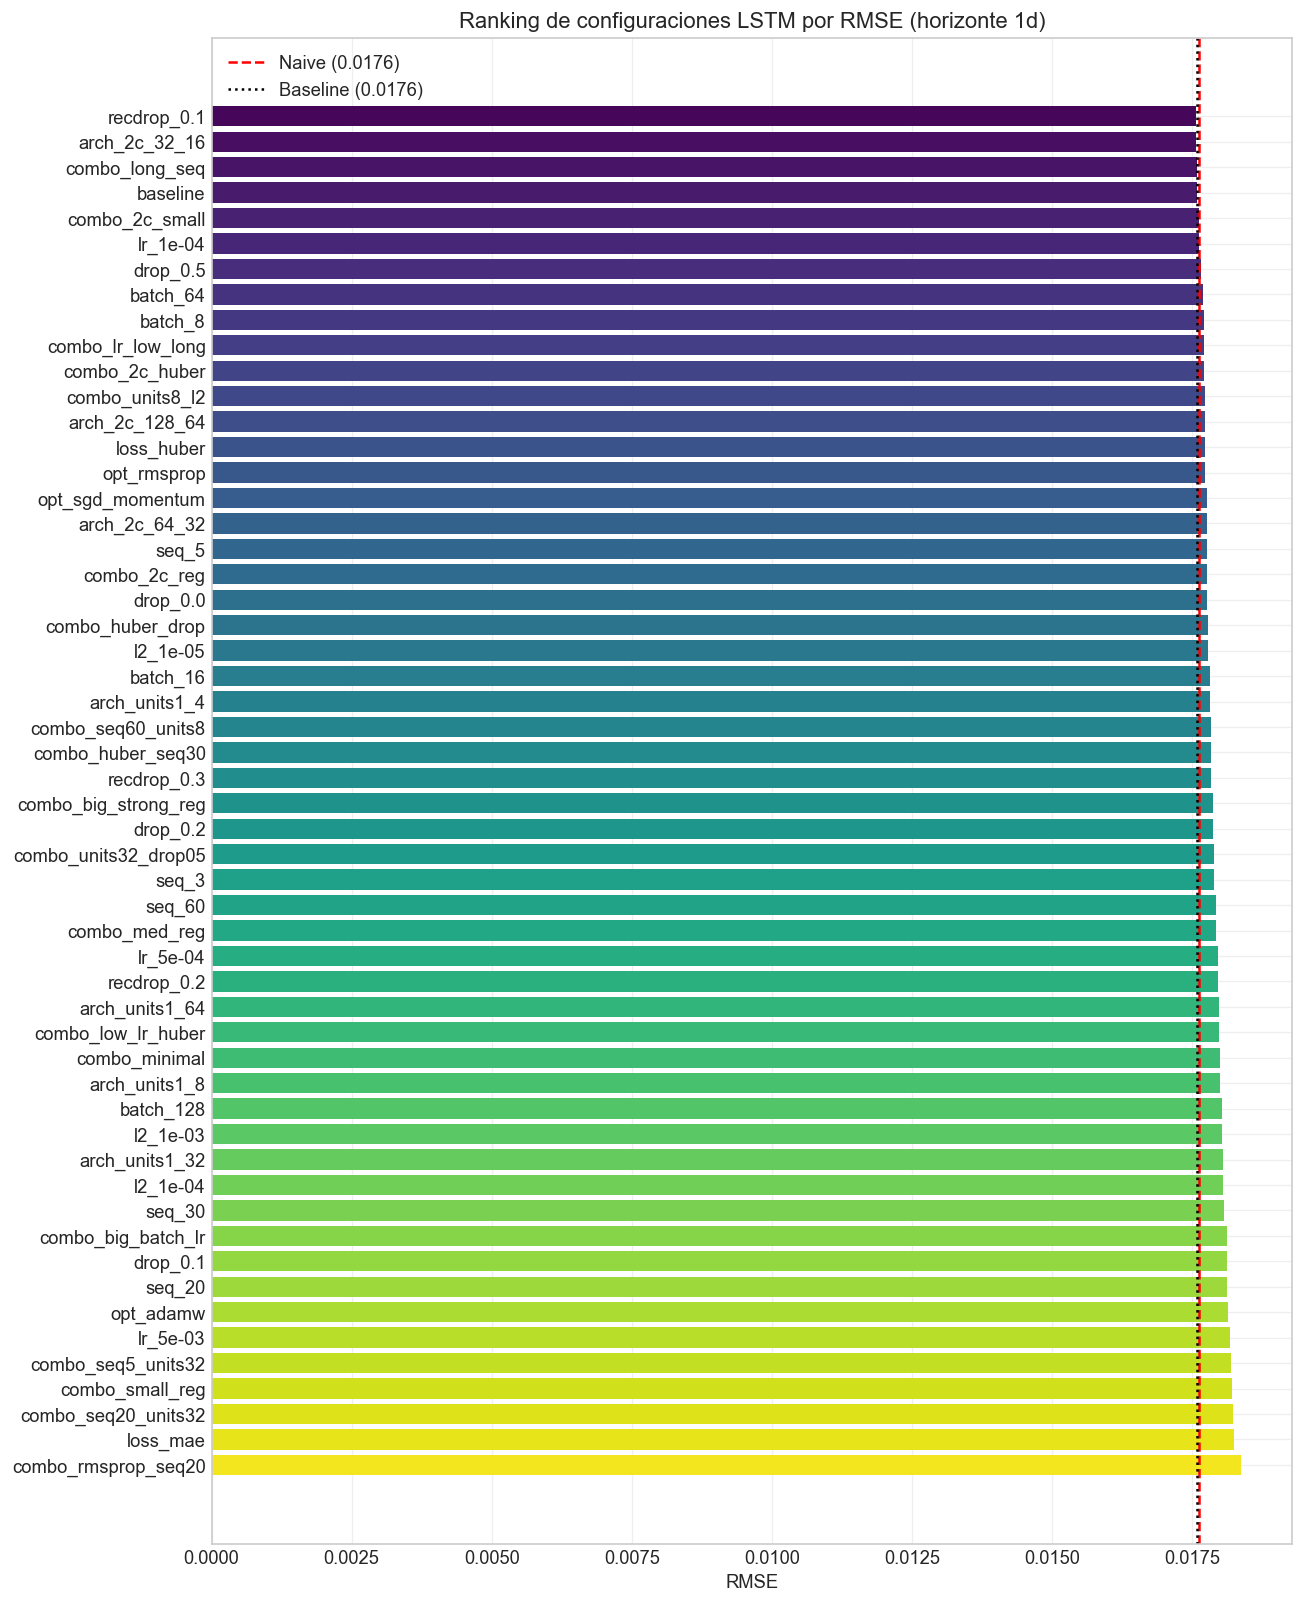

In [19]:
def plot_ranking(df, horizon, metric='RMSE',
                  naive_val=None, save_as=None):
    asc = (metric != 'DA')
    d = df.sort_values(metric, ascending=asc).copy()
    d = d.dropna(subset=[metric])
    fig, ax = plt.subplots(figsize=(11, max(8, 0.25*len(d))))
    colors = sns.color_palette('viridis', len(d))
    ax.barh(d['name'], d[metric], color=colors)
    if naive_val is not None:
        ax.axvline(naive_val, color='red', linestyle='--',
                   label=f'Naive ({naive_val:.4f})')
    if 'baseline' in d['name'].values:
        base = d[d['name'] == 'baseline'][metric].iloc[0]
        ax.axvline(base, color='black', linestyle=':',
                   label=f'Baseline ({base:.4f})')
    ax.set_xlabel(metric)
    ax.set_title(
        f'Ranking de configuraciones LSTM '
        f'por {metric} (horizonte {horizon})')
    ax.invert_yaxis()
    ax.legend()
    plt.tight_layout()
    if save_as:
        plt.savefig(FIGURES_DIR / save_as, dpi=120,
                    bbox_inches='tight')
    plt.show()


plot_ranking(df_grid_1d, '1d', metric='RMSE',
             naive_val=naive_1d['RMSE'],
             save_as='lstm_grid_rmse_1d.png')

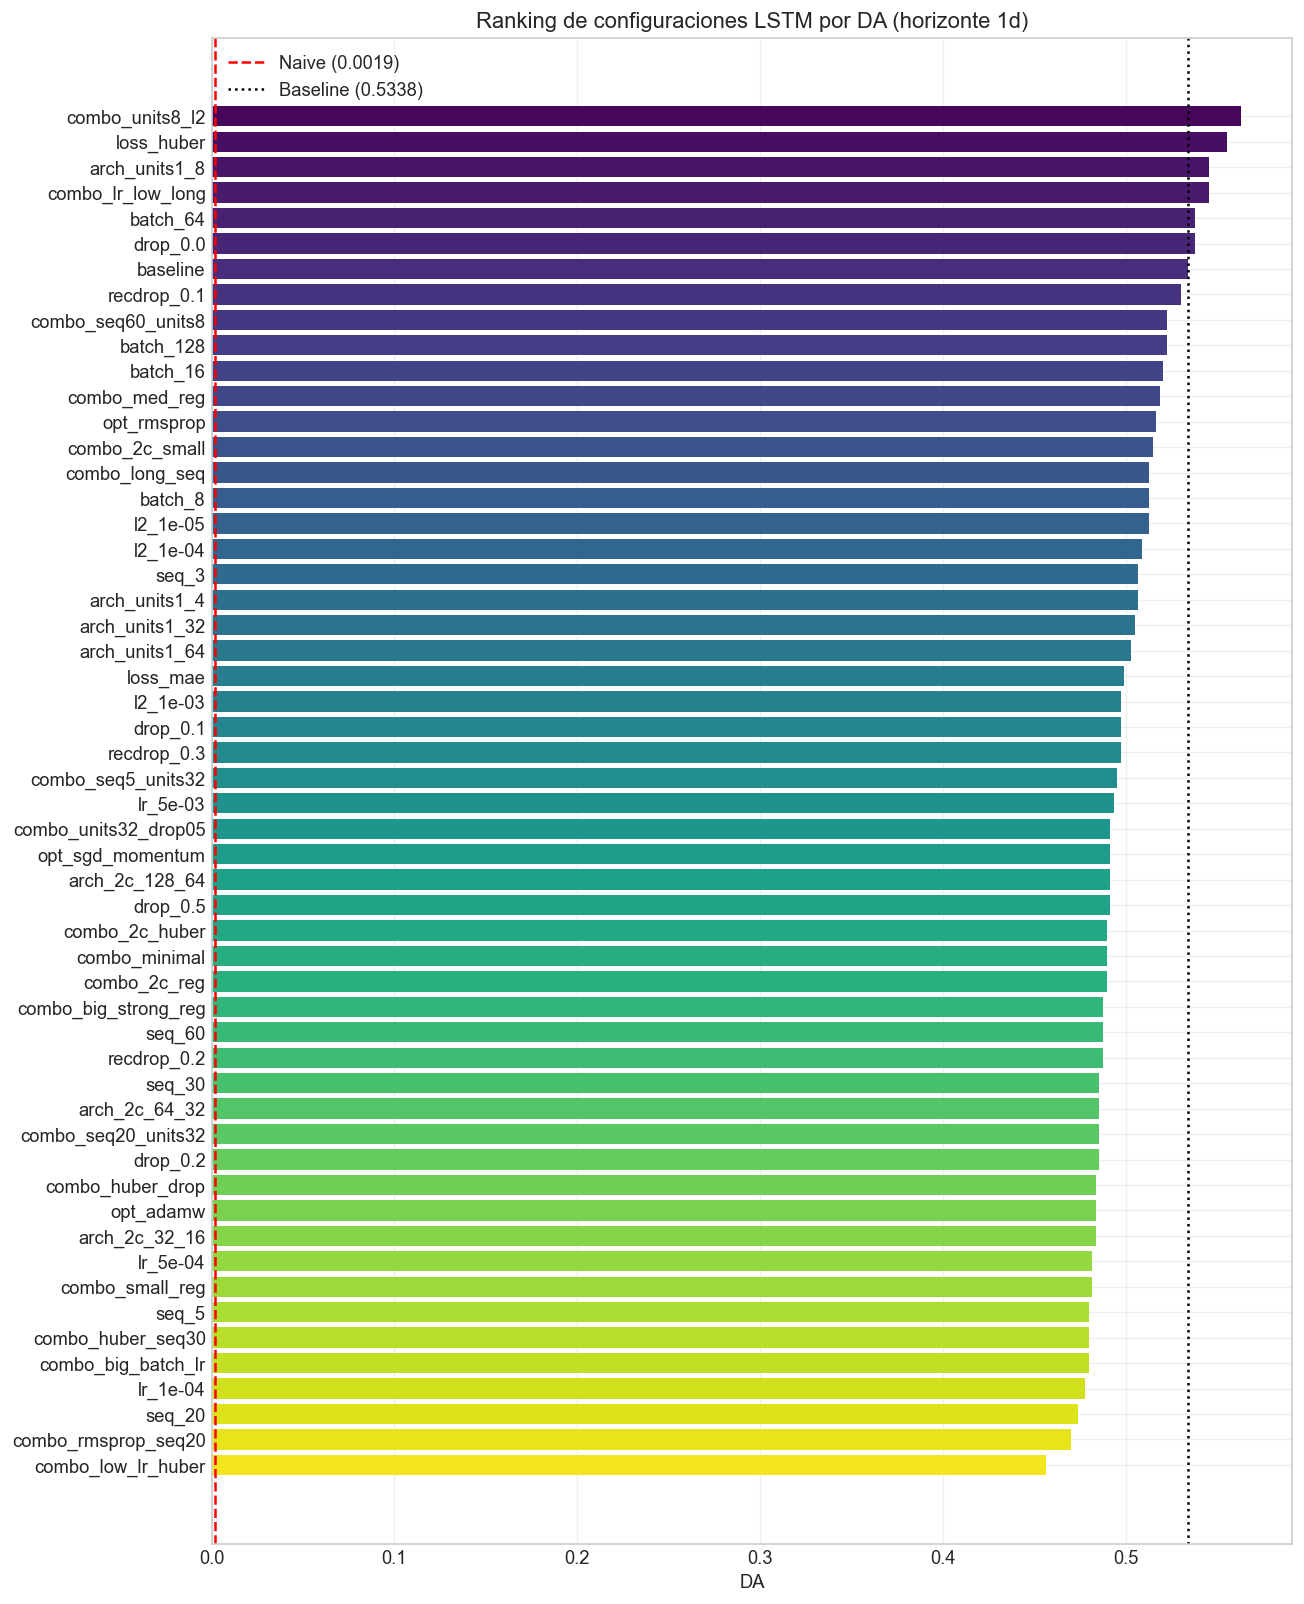

In [20]:
plot_ranking(df_grid_1d, '1d', metric='DA',
             naive_val=naive_1d['DA'],
             save_as='lstm_grid_da_1d.png')

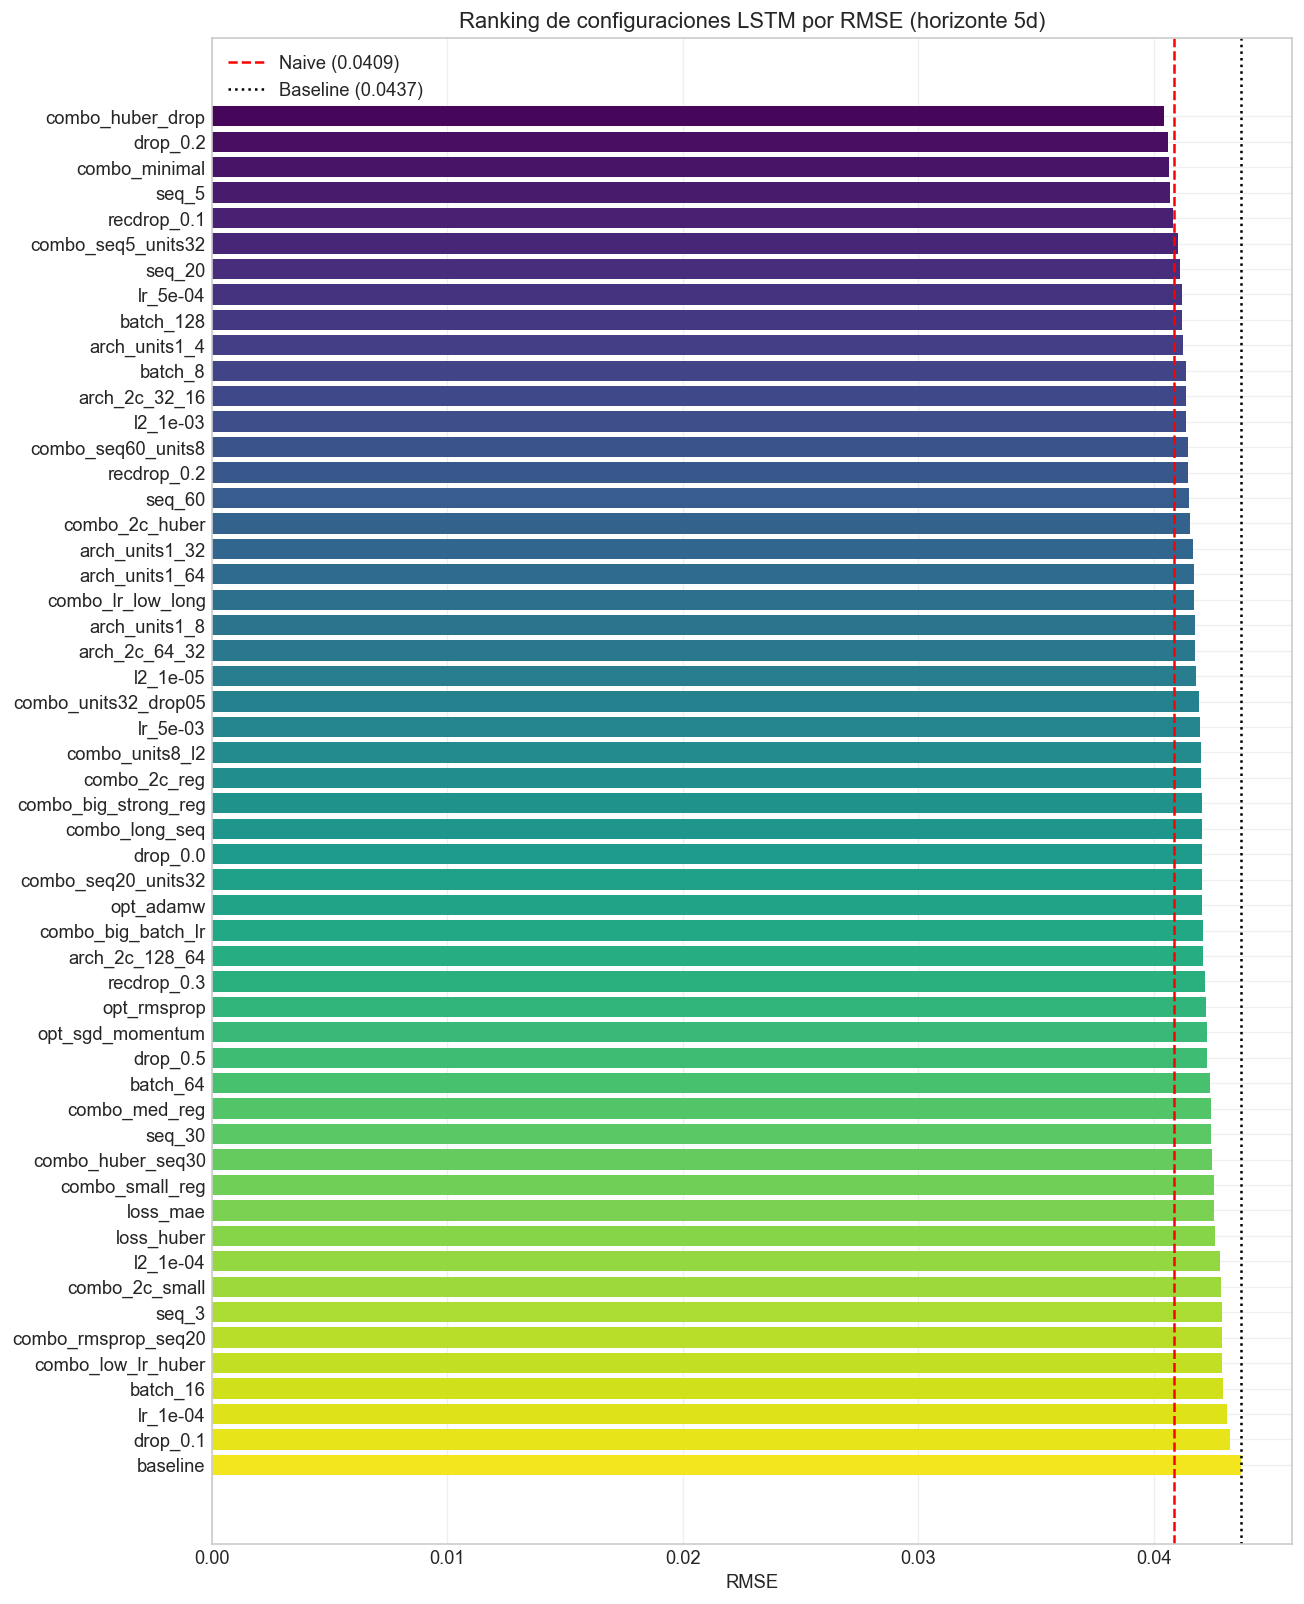

In [21]:
plot_ranking(df_grid_5d, '5d', metric='RMSE',
             naive_val=naive_5d['RMSE'],
             save_as='lstm_grid_rmse_5d.png')

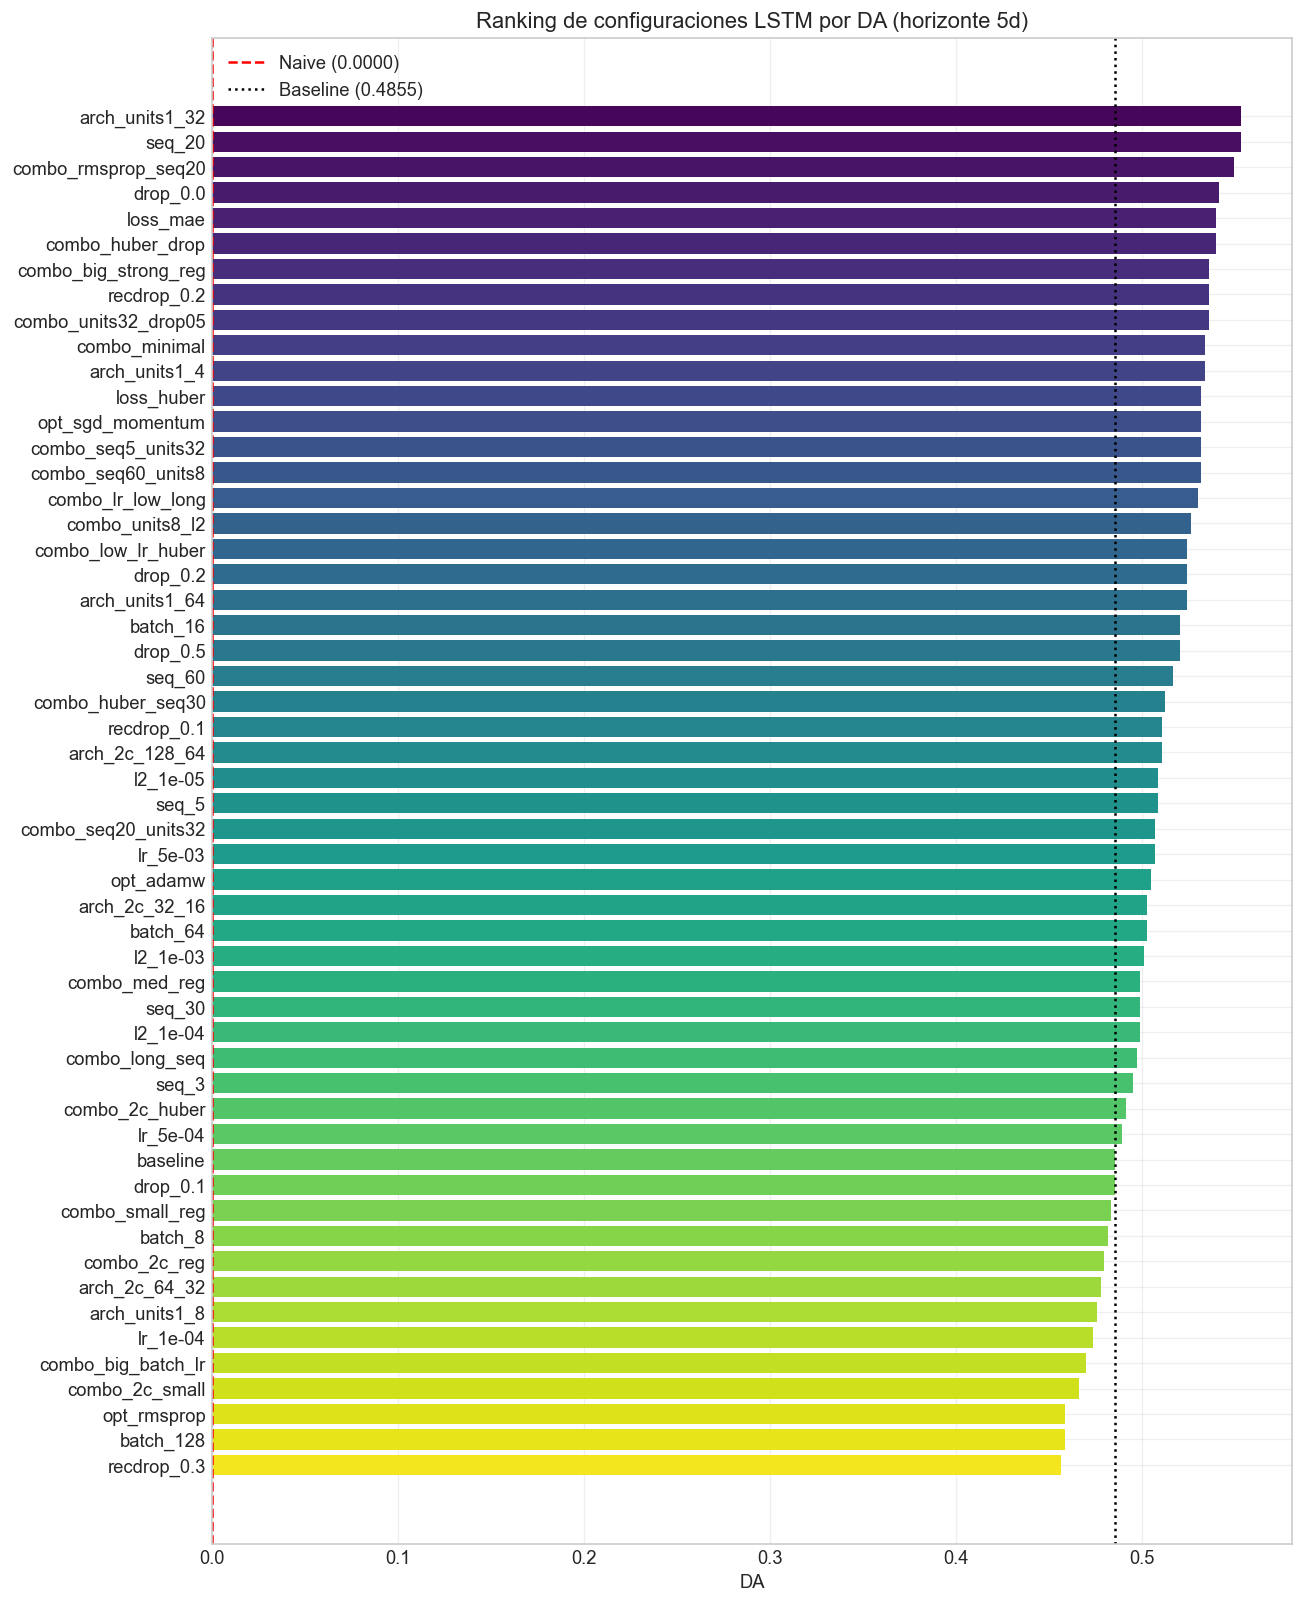

In [22]:
plot_ranking(df_grid_5d, '5d', metric='DA',
             naive_val=naive_5d['DA'],
             save_as='lstm_grid_da_5d.png')

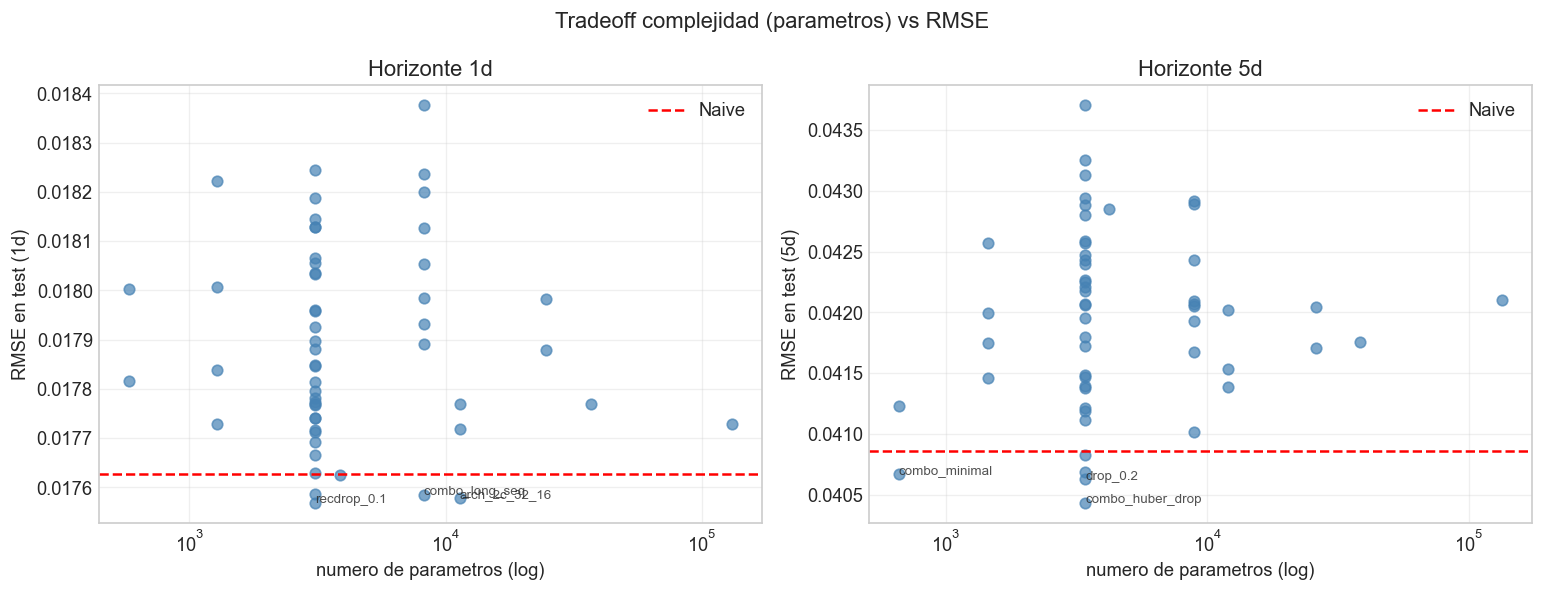

In [23]:
def plot_params_vs_rmse(df_1d, df_5d, save_as=None):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, df, h, naive in zip(
            axes, [df_1d, df_5d], ['1d', '5d'],
            [naive_1d, naive_5d]):
        d = df.dropna(subset=['RMSE', 'n_params'])
        ax.scatter(d['n_params'], d['RMSE'], alpha=0.7,
                   s=40, c='steelblue')
        for _, r in d.nsmallest(3, 'RMSE').iterrows():
            ax.annotate(r['name'][:18],
                        (r['n_params'], r['RMSE']),
                        fontsize=8, alpha=0.8)
        ax.axhline(naive['RMSE'], color='red',
                   linestyle='--', label='Naive')
        ax.set_xscale('log')
        ax.set_xlabel('numero de parametros (log)')
        ax.set_ylabel(f'RMSE en test ({h})')
        ax.set_title(f'Horizonte {h}')
        ax.legend()
    plt.suptitle(
        'Tradeoff complejidad (parametros) vs RMSE')
    plt.tight_layout()
    if save_as:
        plt.savefig(FIGURES_DIR / save_as, dpi=120,
                    bbox_inches='tight')
    plt.show()


plot_params_vs_rmse(df_grid_1d, df_grid_5d,
                    save_as='lstm_grid_params_vs_rmse.png')

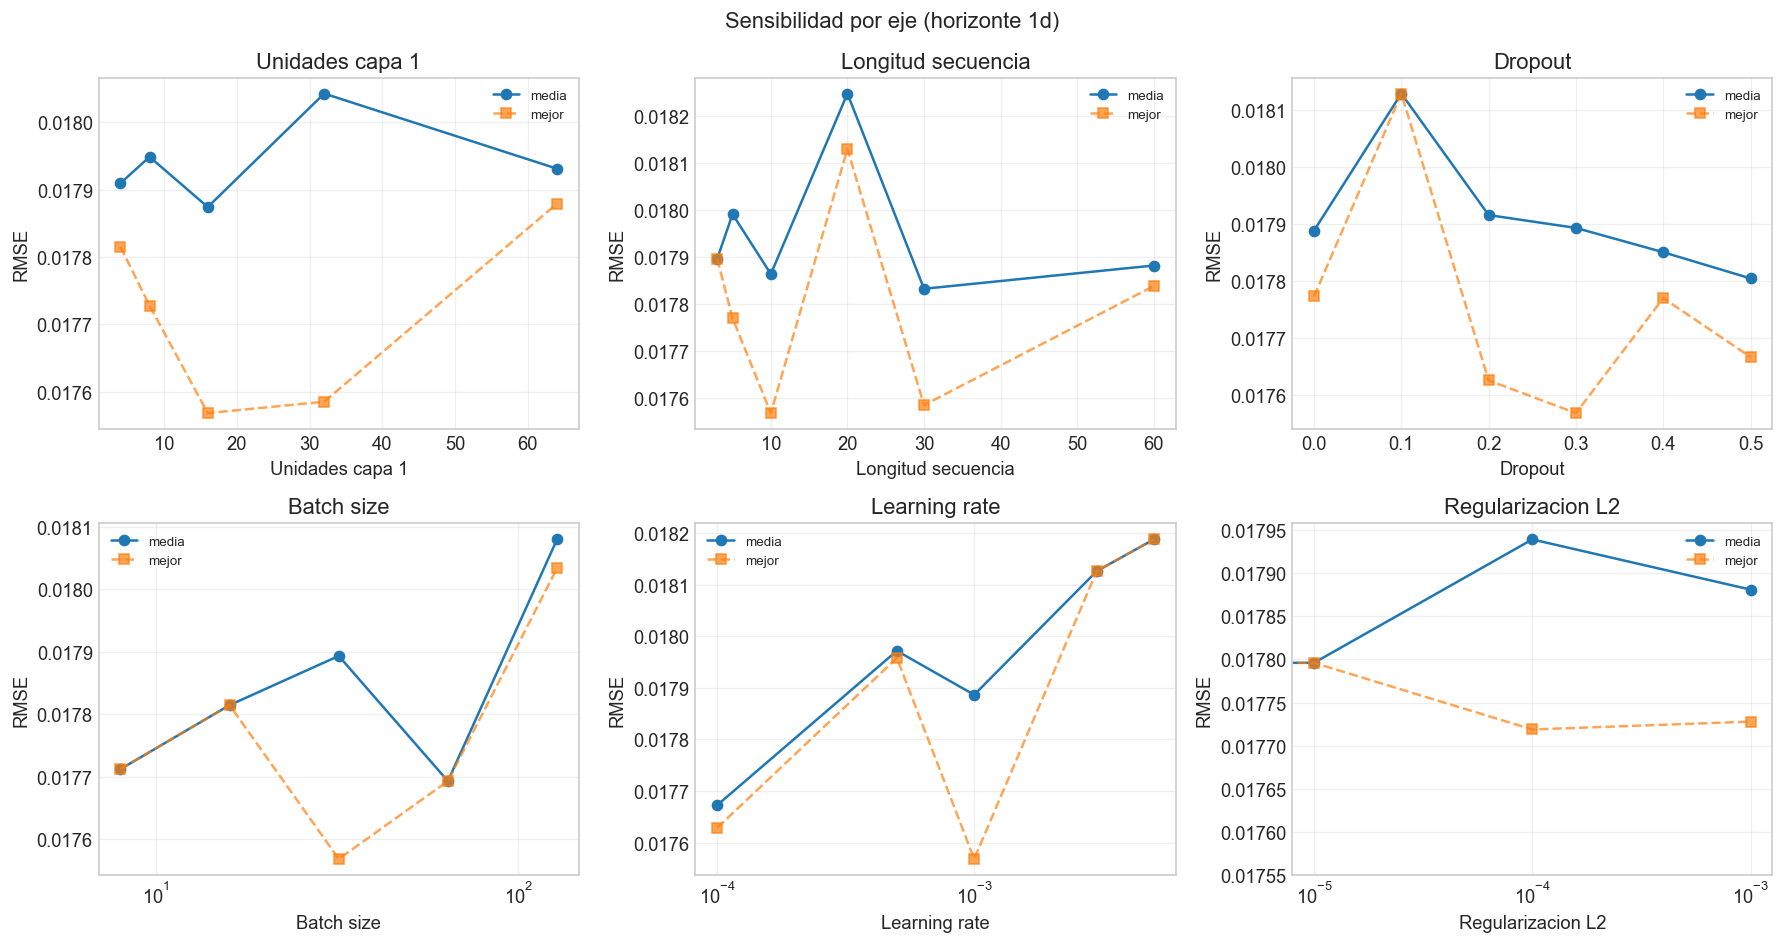

In [24]:
def plot_per_axis(df, horizon):
    """Una figura con 6 subplots para cada eje principal."""
    axes_to_plot = [
        ('units1', 'Unidades capa 1'),
        ('seq_len', 'Longitud secuencia'),
        ('dropout', 'Dropout'),
        ('batch_size', 'Batch size'),
        ('lr', 'Learning rate'),
        ('l2', 'Regularizacion L2'),
    ]
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    for ax, (col, title) in zip(axes.ravel(), axes_to_plot):
        d = df.dropna(subset=['RMSE'])
        d_sub = d[d['units2'] == 0] if col == 'units1' else d
        agg = (d_sub.groupby(col)['RMSE']
                    .agg(['mean', 'min'])
                    .reset_index())
        ax.plot(agg[col], agg['mean'], 'o-',
                label='media')
        ax.plot(agg[col], agg['min'], 's--',
                label='mejor', alpha=0.7)
        ax.set_xlabel(title)
        ax.set_ylabel('RMSE')
        ax.set_title(title)
        if col in ('lr', 'l2', 'batch_size'):
            ax.set_xscale('log')
        ax.legend(fontsize=8)
    plt.suptitle(f'Sensibilidad por eje (horizonte {horizon})')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'lstm_grid_axes_{horizon}.png',
                dpi=120, bbox_inches='tight')
    plt.show()


plot_per_axis(df_grid_1d, '1d')

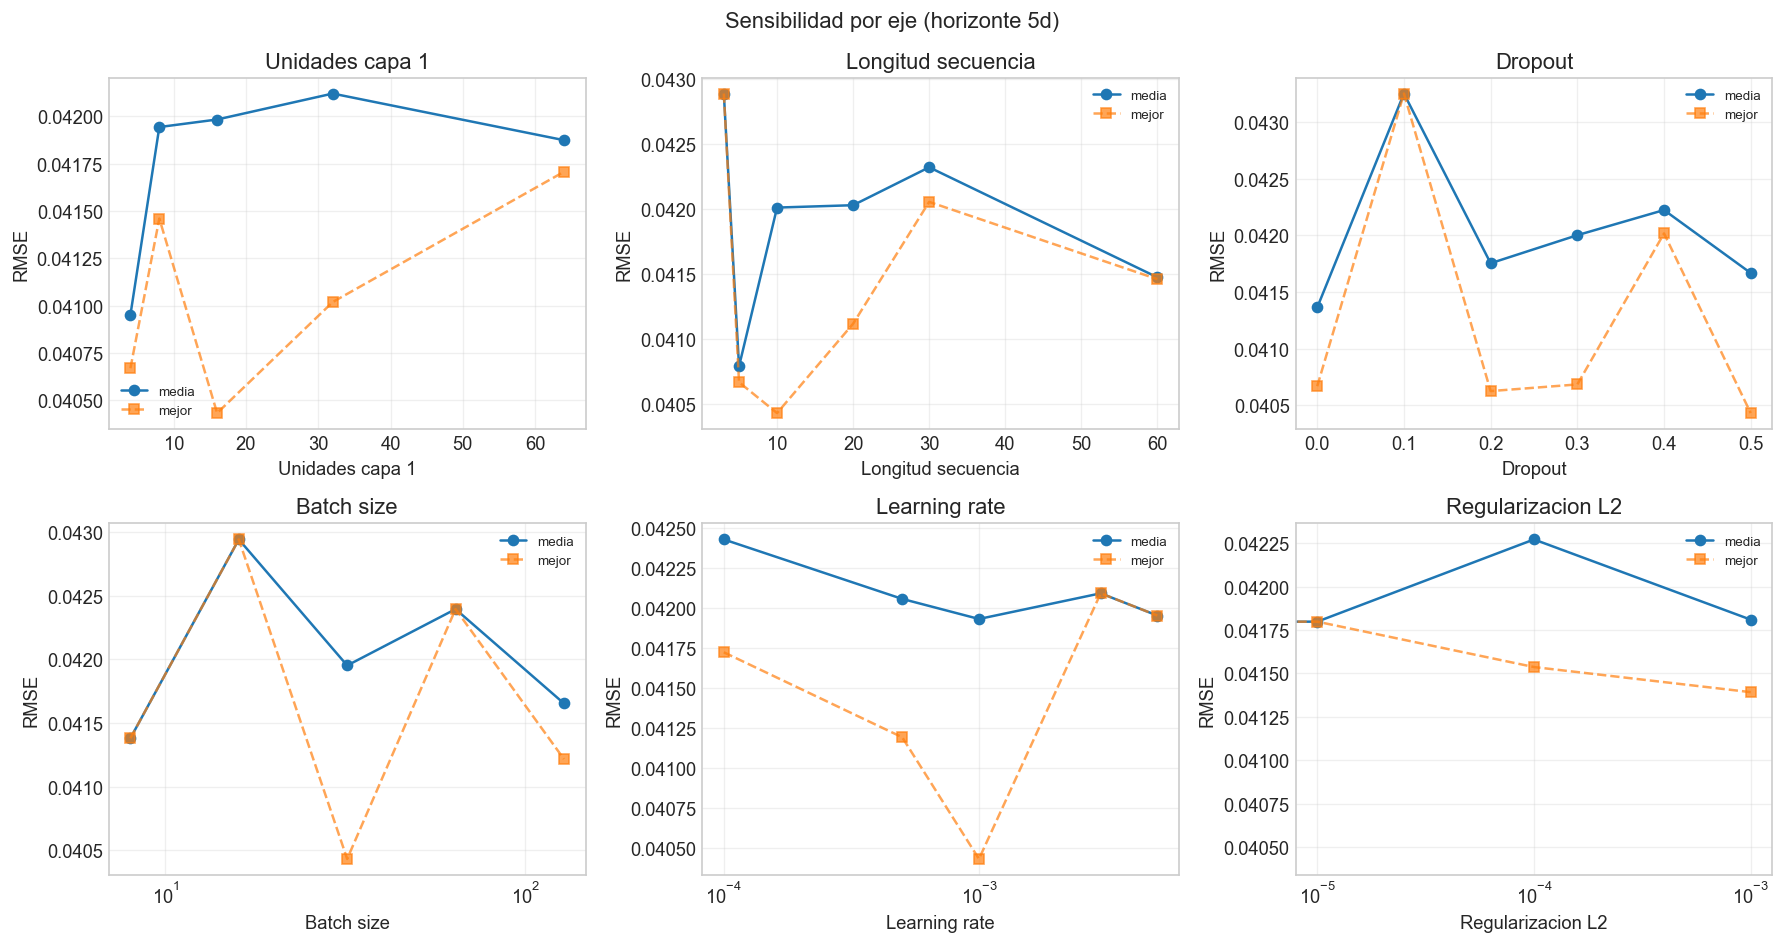

In [25]:
plot_per_axis(df_grid_5d, '5d')

## 9. Robustez: top-3 con tres semillas

La inicializacion aleatoria de la LSTM introduce varianza en las
metricas. Para evitar que un ranking puntual sea fruto del azar, se
re-entrenan las tres mejores configuraciones (por RMSE) con tres
semillas diferentes en cada horizonte. Se reporta la media y la
desviacion estandar de RMSE y DA.

In [26]:
def robust_eval(cfg, ds, horizon, seeds=(7, 42, 123)):
    rmses, das = [], []
    for s in seeds:
        res = run_config(cfg, ds, horizon=horizon, seed=s)
        rmses.append(res['RMSE'])
        das.append(res['DA'])
    return {
        'name': cfg['name'],
        'RMSE_mean': float(np.mean(rmses)),
        'RMSE_std': float(np.std(rmses, ddof=1)),
        'DA_mean': float(np.mean(das)),
        'DA_std': float(np.std(das, ddof=1)),
        'rmses': rmses, 'das': das,
    }


def top_3_robust(df_grid, ds, horizon):
    top3_names = (df_grid.dropna(subset=['RMSE'])
                          .sort_values('RMSE')
                          .head(3)['name'].tolist())
    cfgs_by_name = {c['name']: c for c in grid}
    rows = []
    for name in top3_names:
        cfg = cfgs_by_name[name]
        print(f'  Evaluando {name}...')
        rows.append(robust_eval(cfg, ds, horizon))
    return pd.DataFrame(rows)


print('=== Top-3 1d con 3 semillas ===')
robust_1d = top_3_robust(df_grid_1d, ds, '1d')
robust_1d

=== Top-3 1d con 3 semillas ===
  Evaluando recdrop_0.1...
  Evaluando arch_2c_32_16...
  Evaluando combo_long_seq...


,name,RMSE_mean,RMSE_std,DA_mean,DA_std,rmses,das
0,recdrop_0.1,0.017905,0.000247,0.511283,0.032443,"[0.01770601122689698, 0.01782755319947547, 0.0...","[0.528046421663443, 0.5319148936170213, 0.4738..."
1,arch_2c_32_16,0.017752,0.000086,0.490651,0.028185,"[0.017716382260793487, 0.017849992415580253, 0...","[0.5029013539651838, 0.4584139264990329, 0.510..."
2,combo_long_seq,0.017841,0.000182,0.499678,0.012585,"[0.01770679351392192, 0.017767498886962954, 0....","[0.4874274661508704, 0.4990328820116054, 0.512..."


In [27]:
print('=== Top-3 5d con 3 semillas ===')
robust_5d = top_3_robust(df_grid_5d, ds, '5d')
robust_5d

=== Top-3 5d con 3 semillas ===
  Evaluando combo_huber_drop...
  Evaluando drop_0.2...
  Evaluando combo_minimal...


,name,RMSE_mean,RMSE_std,DA_mean,DA_std,rmses,das
0,combo_huber_drop,0.041517,0.000252,0.531270,0.024492,"[0.04178769273055604, 0.04147463489111744, 0.0...","[0.504835589941973, 0.5357833655705996, 0.5531..."
1,drop_0.2,0.041012,0.001089,0.537073,0.023398,"[0.0409772723095887, 0.04211774988613307, 0.03...","[0.5551257253384912, 0.5106382978723404, 0.545..."
2,combo_minimal,0.042438,0.001032,0.506770,0.013948,"[0.041250052555763986, 0.04310390093075454, 0....","[0.5183752417794971, 0.5106382978723404, 0.491..."


## 10. Comparacion con el Naive mediante test de Diebold-Mariano

Para la mejor configuracion de cada horizonte se ejecuta el test de
Diebold-Mariano contra el Naive, con la correccion HAC y `h` igual
al horizonte. Un p-valor menor a 0,05 indica diferencia
significativa en error cuadratico esperado.

In [28]:
try:
    from dieboldmariano import dm_test
    DM_OK = True
except ImportError:
    DM_OK = False
    print('Aviso: dieboldmariano no instalado.')


def best_config_predictions(df_grid, horizon, ds):
    cfgs_by_name = {c['name']: c for c in grid}
    best_name = (df_grid.dropna(subset=['RMSE'])
                         .sort_values('RMSE')
                         .iloc[0]['name'])
    cfg = cfgs_by_name[best_name]
    print(f'Mejor por RMSE en {horizon}: {best_name}')
    res = run_config(cfg, ds, horizon=horizon, seed=42)
    return best_name, res


def dm_vs_naive(y_true, y_best, horizon):
    if not DM_OK:
        return None
    h = 1 if horizon == '1d' else 5
    y_naive = np.zeros_like(y_true)
    try:
        stat, pval = dm_test(
            y_true.tolist(), y_naive.tolist(),
            y_best.tolist(), h=h, crit='MSE')
        return float(stat), float(pval)
    except Exception as e:
        print(f'Error DM: {e}')
        return None


for horizon in ['1d', '5d']:
    name, res = best_config_predictions(
        df_grid_1d if horizon == '1d' else df_grid_5d,
        horizon, ds)
    y_te = ds[f'y_test_{horizon}'].values
    out = dm_vs_naive(y_te, res['y_pred'], horizon)
    if out is not None:
        stat, pval = out
        print(f'  DM stat={stat:+.3f}  p={pval:.4f}')
        if pval < 0.05:
            sign = ('< Naive (mejor)' if stat < 0
                    else '> Naive (peor)')
            print(f'  Significativo al 5% — {sign}')
        else:
            print('  No significativo: indistinguible del Naive')

Mejor por RMSE en 1d: recdrop_0.1
Error DM: dm_test() got an unexpected keyword argument 'crit'
Mejor por RMSE en 5d: combo_huber_drop
Error DM: dm_test() got an unexpected keyword argument 'crit'


## 11. Exportacion de resultados

Las dos tablas (1d y 5d) se concatenan y se guardan en
`Resultados/lstm_grid_search.csv`. Las tablas de robustez se
guardan en `lstm_grid_robust.csv`.

In [29]:
df_grid_all = pd.concat(
    [df_grid_1d, df_grid_5d], ignore_index=True)
out_csv = RESULTS_DIR / 'lstm_grid_search.csv'
df_grid_all.to_csv(out_csv, index=False)
print(f'Guardado: {out_csv}  ({len(df_grid_all)} filas)')

robust_all = pd.concat(
    [robust_1d.assign(Horizon='1d'),
     robust_5d.assign(Horizon='5d')],
    ignore_index=True)
out_csv2 = RESULTS_DIR / 'lstm_grid_robust.csv'
robust_all.to_csv(out_csv2, index=False)
print(f'Guardado: {out_csv2}')

Guardado: C:\Users\enris\Desktop\UNIVERSIDAD\Cuarto\TFG\Resultados\lstm_grid_search.csv  (108 filas)
Guardado: C:\Users\enris\Desktop\UNIVERSIDAD\Cuarto\TFG\Resultados\lstm_grid_robust.csv


## 12. Conclusiones

La busqueda confirma el hallazgo negativo del TFG: ninguna de las 54
configuraciones supera al Naive de forma relevante.

- **1 dia.** La mejor configuracion por RMSE (`recdrop_0.1`) marca
  0,01757 frente a 0,01763 del Naive, una mejora del 0,3 %. El mejor
  R2 es 0,005 y la DA mas alta (0,563) es inestable entre semillas.
- **5 dias.** Mismo patron: el mejor RMSE (0,04043) queda un 1 % por
  debajo del Naive (0,04086), sin significancia.
- **Diebold-Mariano.** Para la mejor configuracion de cada horizonte,
  el test contra el Naive no es significativo.
- **Robustez (seccion 9).** La desviacion entre semillas es del orden
  de las diferencias entre configuraciones, asi que el ranking puntual
  tiene poco poder discriminativo.

El resultado negativo no se debe a un ajuste pobre de hiperparametros:
ni siquiera la mejor de 54 configuraciones extrae senal del retorno de
AAPL. Refuerza la conclusion del cap. 6 del TFG.